# ⚡ Boosting: AdaBoost → Gradient Boosting → XGBoost
### From First Principles to Production

---

**The big idea:** Instead of training many independent trees (Random Forest), boosting trains trees **sequentially** — each tree corrects the mistakes of all previous trees.

| Algorithm | Year | Core Idea |
|-----------|------|-----------|
| AdaBoost | 1997 | Re-weight misclassified samples |
| Gradient Boosting | 1999 | Fit residuals using gradient descent in function space |
| XGBoost | 2016 | Regularised GB + second-order Taylor expansion |

**What you'll build from scratch:**
1. AdaBoost — complete, from numpy
2. Gradient Boosting Classifier & Regressor — complete, from numpy
3. XGBoost — conceptual internals + `xgboost` library for full power

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import Counter

plt.rcParams.update({
    'figure.facecolor': '#0a0a12',
    'axes.facecolor':   '#11111f',
    'axes.edgecolor':   '#2a2a3f',
    'axes.labelcolor':  '#d0d0e8',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'text.color':       '#d0d0e8',
    'grid.color':       '#1e1e30',
    'grid.linestyle':   '--',
    'grid.alpha':       0.7,
    'font.family':      'monospace',
    'legend.facecolor': '#11111f',
    'legend.edgecolor': '#2a2a3f',
})

CYAN   = '#00ffcc'
PINK   = '#ff4f8b'
YELLOW = '#ffe066'
PURPLE = '#aa88ff'
ORANGE = '#ff8c42'
GREEN  = '#44ff99'
BLUE   = '#4488ff'

np.random.seed(42)
print('✅ Ready. Let\'s boost.')

✅ Ready. Let's boost.


---
# PART I — AdaBoost

## 1.1 The Intuition

AdaBoost (Adaptive Boosting) works by:
1. Assign **equal weights** to all training samples
2. Train a **weak learner** (shallow tree — just a stump)
3. **Increase weights** of misclassified samples — they get more attention next round
4. **Decrease weights** of correctly classified samples
5. Train the next stump on re-weighted data
6. Repeat T times, then take a **weighted majority vote**

The key insight: each stump specialises on what the previous stumps got wrong.

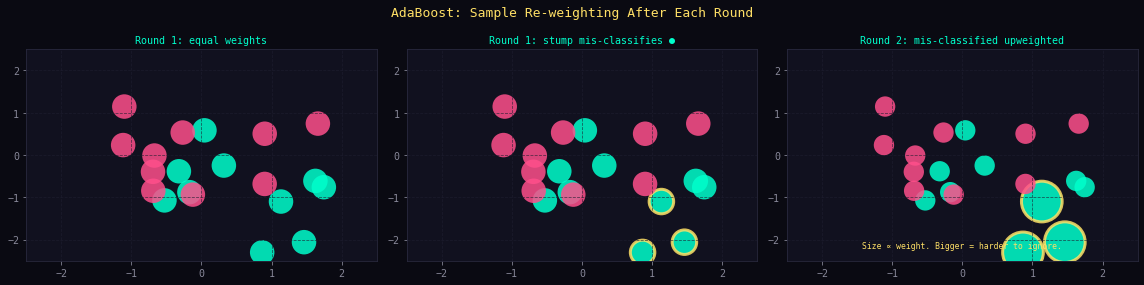

In [2]:
# ── Visualise the AdaBoost weight update idea ──────────────────────
np.random.seed(1)
n_demo = 20
X_demo = np.random.randn(n_demo, 2)
y_demo = np.array([1]*10 + [-1]*10)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Round 1: uniform weights
w1 = np.ones(n_demo) / n_demo
misclassified = [2, 5, 7]   # pretend stump 1 misses these

for ax, weights, title, miss in [
    (axes[0], w1, 'Round 1: equal weights', []),
    (axes[1], w1, 'Round 1: stump mis-classifies ●', misclassified),
    (axes[2], None, 'Round 2: mis-classified upweighted', misclassified),
]:
    w = weights if weights is not None else w1.copy()
    if ax == axes[2]:
        w[miss] *= 4   # up-weight misclassified
        w /= w.sum()

    sizes = w * n_demo * 600
    colors = [CYAN if yi == 1 else PINK for yi in y_demo]
    edge_colors = [YELLOW if i in miss else 'none' for i in range(n_demo)]
    lwidths = [3 if i in miss else 0 for i in range(n_demo)]

    ax.scatter(X_demo[:, 0], X_demo[:, 1], s=sizes, c=colors,
               edgecolors=edge_colors, linewidths=lwidths, alpha=0.85)
    ax.set_title(title, color=CYAN, fontsize=10)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.grid(True)
    if ax == axes[2]:
        ax.text(0, -2.2, 'Size ∝ weight. Bigger = harder to ignore.',
                ha='center', color=YELLOW, fontsize=8)

plt.suptitle('AdaBoost: Sample Re-weighting After Each Round', color=YELLOW, fontsize=13)
plt.tight_layout(); plt.show()

## 1.2 The Math

**Stump weight** — how much to trust stump $t$:
$$\alpha_t = \frac{1}{2} \ln\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)$$

where $\epsilon_t$ = weighted error rate. If the stump is better than random ($\epsilon_t < 0.5$), then $\alpha_t > 0$.

**Weight update** for each sample $i$:
$$w_i^{(t+1)} = w_i^{(t)} \cdot e^{-\alpha_t \, y_i \, h_t(x_i)}$$

If correctly classified: $y_i h_t(x_i) = +1$ → weight **decreases** by $e^{-\alpha_t}$  
If misclassified: $y_i h_t(x_i) = -1$ → weight **increases** by $e^{+\alpha_t}$

**Final prediction**: $H(x) = \text{sign}\left(\sum_t \alpha_t h_t(x)\right)$

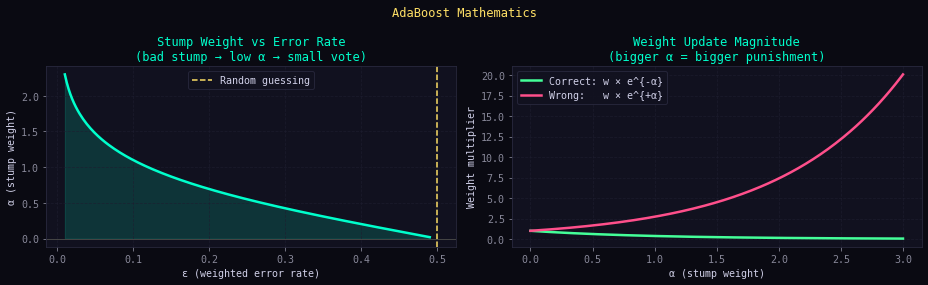

In [3]:
# ── Visualise alpha vs error rate ──────────────────────────────────
eps = np.linspace(0.01, 0.49, 200)
alpha = 0.5 * np.log((1 - eps) / eps)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(eps, alpha, color=CYAN, lw=2.5)
axes[0].axhline(0, color='#444', lw=1)
axes[0].axvline(0.5, color=YELLOW, lw=1.5, linestyle='--', label='Random guessing')
axes[0].fill_between(eps, 0, alpha, alpha=0.15, color=CYAN)
axes[0].set_xlabel('ε (weighted error rate)')
axes[0].set_ylabel('α (stump weight)')
axes[0].set_title('Stump Weight vs Error Rate\n(bad stump → low α → small vote)', color=CYAN)
axes[0].legend(); axes[0].grid(True)

# Weight multiplier for correct vs incorrect
alpha_vals = np.linspace(0, 3, 200)
axes[1].plot(alpha_vals, np.exp(-alpha_vals), color=GREEN, lw=2.5, label='Correct: w × e^{-α}')
axes[1].plot(alpha_vals, np.exp(+alpha_vals), color=PINK,  lw=2.5, label='Wrong:   w × e^{+α}')
axes[1].set_xlabel('α (stump weight)')
axes[1].set_ylabel('Weight multiplier')
axes[1].set_title('Weight Update Magnitude\n(bigger α = bigger punishment)', color=CYAN)
axes[1].legend(); axes[1].grid(True)

plt.suptitle('AdaBoost Mathematics', color=YELLOW, fontsize=12)
plt.tight_layout(); plt.show()

## 1.3 AdaBoost — Built From Scratch

In [4]:
class DecisionStump:
    """A depth-1 decision tree (stump) — the weak learner for AdaBoost."""

    def __init__(self):
        self.feature   = None
        self.threshold = None
        self.polarity  = 1     # +1 or -1: flip if stump is better inverted
        self.alpha     = None  # this stump's vote weight

    def fit(self, X, y, weights):
        """
        Find the feature/threshold that minimises weighted error.
        y must be in {-1, +1}.
        """
        n, p = X.shape
        best_error = np.inf

        for feat in range(p):
            thresholds = np.unique(X[:, feat])
            for thresh in thresholds:
                for polarity in [1, -1]:
                    preds = np.where(X[:, feat] <= thresh, polarity, -polarity)
                    # Weighted error = sum of weights of misclassified samples
                    error = np.sum(weights[preds != y])
                    if error < best_error:
                        best_error = error
                        self.feature   = feat
                        self.threshold = thresh
                        self.polarity  = polarity

        return best_error

    def predict(self, X):
        return np.where(X[:, self.feature] <= self.threshold,
                        self.polarity, -self.polarity)


class AdaBoostClassifier:
    """AdaBoost from scratch. Labels must be {-1, +1}."""

    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.stumps       = []
        self.alphas       = []
        self.history      = []   # (train_error, weighted_error) per round

    def fit(self, X, y):
        n = len(y)
        w = np.ones(n) / n       # uniform weights to start

        for t in range(self.n_estimators):
            stump = DecisionStump()
            eps   = stump.fit(X, y, w)

            # Clamp eps to avoid log(0)
            eps = np.clip(eps, 1e-10, 1 - 1e-10)

            # Stump vote weight
            alpha = 0.5 * np.log((1 - eps) / eps)
            stump.alpha = alpha

            # Weight update (vectorised)
            w = w * np.exp(-alpha * y * stump.predict(X))
            w /= w.sum()   # normalise to probability distribution

            train_err = np.mean(self.predict(X, up_to=t+1) != y)
            self.history.append((train_err, eps, alpha))
            self.stumps.append(stump)
            self.alphas.append(alpha)

        return self

    def predict(self, X, up_to=None):
        stumps = self.stumps[:up_to] if up_to else self.stumps
        alphas = self.alphas[:up_to] if up_to else self.alphas
        # Weighted vote sum
        vote_sum = sum(a * s.predict(X) for a, s in zip(alphas, stumps))
        return np.sign(vote_sum)

    def staged_score(self, X, y):
        """Accuracy after each successive stump is added."""
        return [np.mean(self.predict(X, up_to=t+1) == y)
                for t in range(len(self.stumps))]


print('AdaBoostClassifier defined ✓')

AdaBoostClassifier defined ✓


In [5]:
# ── Generate dataset & train ───────────────────────────────────────
def make_moons_manual(n=400, noise=0.25):
    n2 = n // 2
    theta1 = np.linspace(0, np.pi, n2)
    theta2 = np.linspace(0, np.pi, n2)
    X1 = np.column_stack([np.cos(theta1), np.sin(theta1)])
    X2 = np.column_stack([1 - np.cos(theta2), -np.sin(theta2) + 0.5])
    X  = np.vstack([X1, X2]) + np.random.randn(n, 2) * noise
    y  = np.array([-1]*n2 + [1]*n2)
    return X, y

X_moon, y_moon = make_moons_manual(400)
split = 300
X_tr, X_te = X_moon[:split], X_moon[split:]
y_tr, y_te = y_moon[:split], y_moon[split:]

ada = AdaBoostClassifier(n_estimators=100)
ada.fit(X_tr, y_tr)

train_acc = ada.staged_score(X_tr, y_tr)
test_acc  = ada.staged_score(X_te, y_te)

print(f'Final train accuracy: {train_acc[-1]:.4f}')
print(f'Final test  accuracy: {test_acc[-1]:.4f}')

Final train accuracy: 0.9900
Final test  accuracy: 0.4200


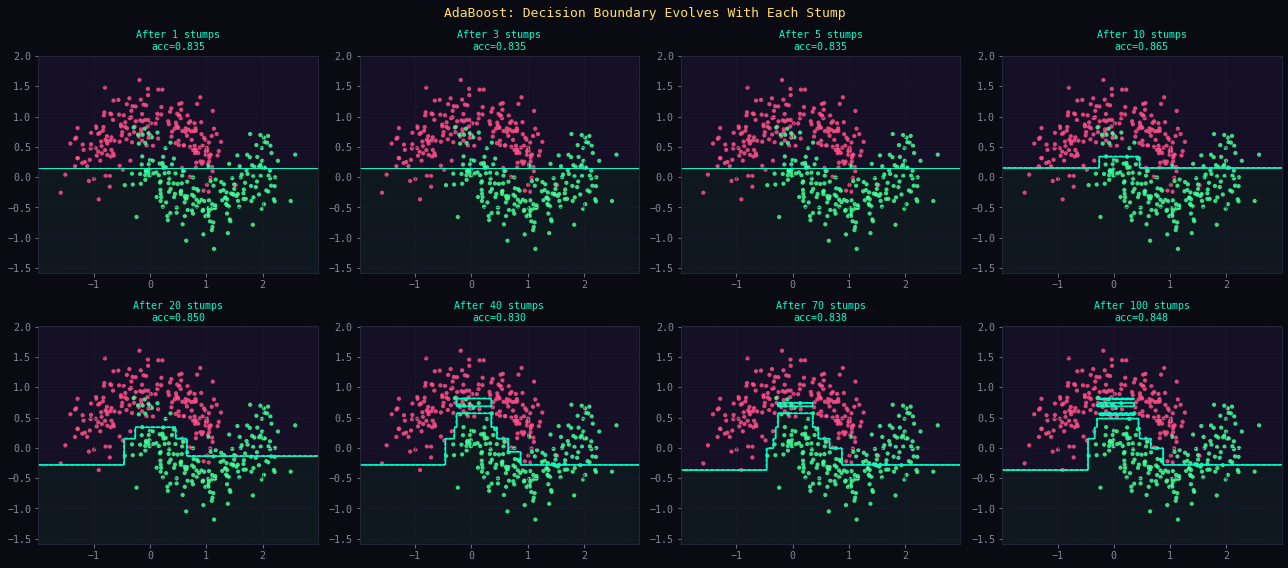

In [6]:
def plot_boundary(model, X, y, ax, title, res=250, label_map=None):
    x0_min, x0_max = X[:,0].min()-0.4, X[:,0].max()+0.4
    x1_min, x1_max = X[:,1].min()-0.4, X[:,1].max()+0.4
    xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, res),
                         np.linspace(x1_min, x1_max, res))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cmap_bg = ListedColormap(['#1a1030', '#0d2020'])
    ax.contourf(xx, yy, Z, alpha=0.45, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors=[CYAN], linewidths=1, alpha=0.6)
    colors = [PINK if yi == -1 else GREEN for yi in y]
    ax.scatter(X[:,0], X[:,1], c=colors, s=18, edgecolors='none', alpha=0.85)
    acc = np.mean(model.predict(X) == y)
    ax.set_title(f'{title}\nacc={acc:.3f}', color=CYAN, fontsize=10)
    ax.grid(True)

# Show decision boundary evolution
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
rounds = [1, 3, 5, 10, 20, 40, 70, 100]

for ax, r in zip(axes.ravel(), rounds):
    class Proxy:
        def __init__(self, model, r): self.m, self.r = model, r
        def predict(self, X): return self.m.predict(X, up_to=self.r)
    plot_boundary(Proxy(ada, r), X_moon, y_moon, ax, f'After {r} stumps')

plt.suptitle('AdaBoost: Decision Boundary Evolves With Each Stump', color=YELLOW, fontsize=13)
plt.tight_layout(); plt.show()

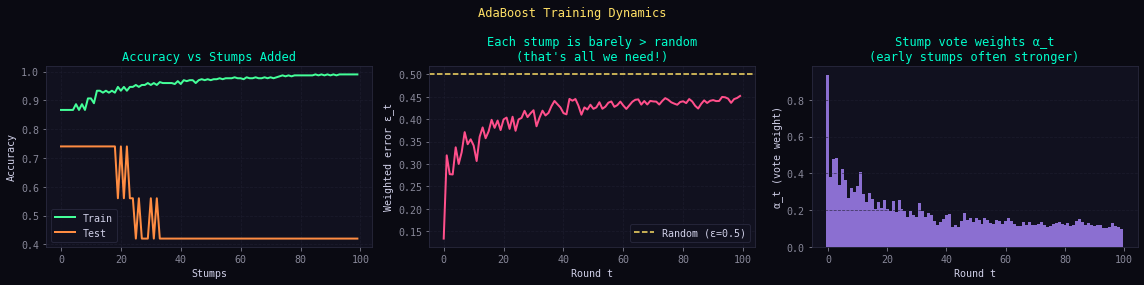

In [7]:
hist = np.array(ada.history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Accuracy curve
axes[0].plot(train_acc, color=GREEN,  lw=2, label='Train')
axes[0].plot(test_acc,  color=ORANGE, lw=2, label='Test')
axes[0].set_xlabel('Stumps'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Stumps Added', color=CYAN)
axes[0].legend(); axes[0].grid(True)

# Weighted error per stump
axes[1].plot(hist[:, 1], color=PINK, lw=2)
axes[1].axhline(0.5, color=YELLOW, lw=1.5, linestyle='--', label='Random (ε=0.5)')
axes[1].set_xlabel('Round t'); axes[1].set_ylabel('Weighted error ε_t')
axes[1].set_title('Each stump is barely > random\n(that\'s all we need!)', color=CYAN)
axes[1].legend(); axes[1].grid(True)

# Alpha values
axes[2].bar(range(len(hist)), hist[:, 2], color=PURPLE, alpha=0.8, width=1.0)
axes[2].set_xlabel('Round t'); axes[2].set_ylabel('α_t (vote weight)')
axes[2].set_title('Stump vote weights α_t\n(early stumps often stronger)', color=CYAN)
axes[2].grid(True, axis='y')

plt.suptitle('AdaBoost Training Dynamics', color=YELLOW, fontsize=12)
plt.tight_layout(); plt.show()

---
# PART II — Gradient Boosting

## 2.1 The Unifying Insight: Boosting as Gradient Descent

AdaBoost re-weights samples. Friedman (1999) showed this is a special case of a much more general framework:

> **Train each new tree to predict the negative gradient of the loss function on the current residuals.**

This means we can plug in **any differentiable loss function** — MSE for regression, log-loss for classification, quantile loss, etc.

**The algorithm:**
1. Start with a constant prediction $F_0(x) = \text{mean}(y)$
2. For $t = 1, 2, \ldots, T$:
   - Compute **pseudo-residuals** (negative gradient of loss): $r_i = -\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}$
   - Fit a tree $h_t$ to the pseudo-residuals
   - Update: $F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$

$\eta$ is the **learning rate** — how much each tree contributes.

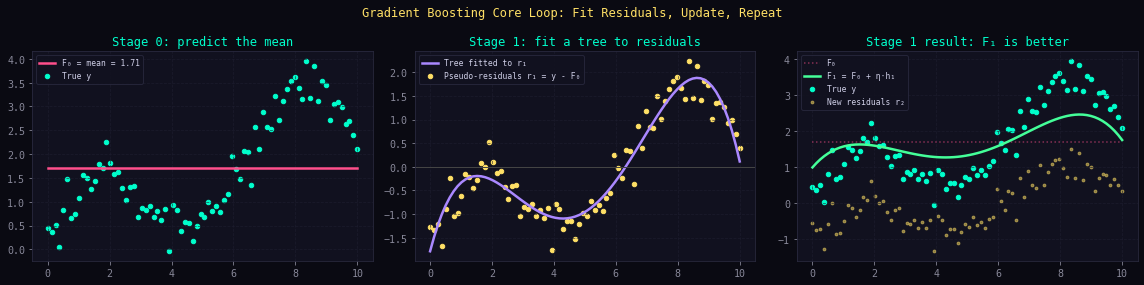

In [8]:
# ── Visualise pseudo-residuals (the key concept) ──────────────────
x1d = np.linspace(0, 10, 80)
y1d = np.sin(x1d) + 0.3*x1d + np.random.randn(80)*0.3

# Stage 0: predict the mean
F0 = np.full_like(y1d, y1d.mean())
r1 = y1d - F0   # residuals after stage 0 (for MSE, gradient = residual)

# Fit a shallow tree to residuals (simulate with a polynomial for clarity)
from numpy.polynomial import polynomial as P
coef = np.polyfit(x1d, r1, 4)
h1 = np.polyval(coef, x1d)
lr = 0.4
F1 = F0 + lr * h1
r2 = y1d - F1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(x1d, y1d, color=CYAN, s=20, label='True y')
axes[0].plot(x1d, F0, color=PINK, lw=2.5, label=f'F₀ = mean = {y1d.mean():.2f}')
axes[0].set_title('Stage 0: predict the mean', color=CYAN)
axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].scatter(x1d, r1, color=YELLOW, s=20, label='Pseudo-residuals r₁ = y - F₀')
axes[1].plot(x1d, h1, color=PURPLE, lw=2.5, label='Tree fitted to r₁')
axes[1].axhline(0, color='#444', lw=1)
axes[1].set_title('Stage 1: fit a tree to residuals', color=CYAN)
axes[1].legend(fontsize=8); axes[1].grid(True)

axes[2].scatter(x1d, y1d, color=CYAN, s=20, label='True y')
axes[2].plot(x1d, F0, color=PINK, lw=1.5, linestyle=':', alpha=0.5, label='F₀')
axes[2].plot(x1d, F1, color=GREEN, lw=2.5, label=f'F₁ = F₀ + η·h₁')
axes[2].scatter(x1d, r2, color=YELLOW, s=8, alpha=0.5, label='New residuals r₂')
axes[2].set_title('Stage 1 result: F₁ is better', color=CYAN)
axes[2].legend(fontsize=8); axes[2].grid(True)

plt.suptitle('Gradient Boosting Core Loop: Fit Residuals, Update, Repeat', color=YELLOW, fontsize=12)
plt.tight_layout(); plt.show()

## 2.2 Gradients of Different Loss Functions

| Task | Loss $L(y, F)$ | Pseudo-residual $r_i$ |
|------|----------------|----------------------|
| Regression | $\frac{1}{2}(y-F)^2$ | $y - F$ |
| Classification | $\log(1 + e^{-yF})$ | $y - \sigma(F)$ (where $\sigma$ is sigmoid) |
| Robust regression | $|y - F|$ | $\text{sign}(y - F)$ |

In [9]:
# ── Decision tree we'll reuse for GBM ─────────────────────────────
class SimpleRegressionTree:
    """
    Shallow regression tree for Gradient Boosting.
    Finds the best single split that minimises MSE of residuals.
    Supports arbitrary depth via recursion.
    """
    class _Node:
        def __init__(self, feat=None, thresh=None, left=None, right=None, val=None):
            self.feat=feat; self.thresh=thresh
            self.left=left; self.right=right; self.val=val
        def is_leaf(self): return self.val is not None

    def __init__(self, max_depth=3, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _mse(self, y):
        return np.var(y) if len(y) > 0 else 0.0

    def _best_split(self, X, y):
        best_gain, best_f, best_t = -np.inf, None, None
        base = self._mse(y)
        n = len(y)
        for f in range(X.shape[1]):
            for t in np.unique(X[:, f])[:-1]:
                lm = X[:, f] <= t
                if lm.sum() < 1 or (~lm).sum() < 1: continue
                gain = base - (lm.sum()/n)*self._mse(y[lm]) - ((~lm).sum()/n)*self._mse(y[~lm])
                if gain > best_gain:
                    best_gain, best_f, best_t = gain, f, t
        return best_f, best_t

    def _build(self, X, y, depth=0):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return self._Node(val=np.mean(y))
        f, t = self._best_split(X, y)
        if f is None: return self._Node(val=np.mean(y))
        lm = X[:, f] <= t
        return self._Node(feat=f, thresh=t,
                          left=self._build(X[lm], y[lm], depth+1),
                          right=self._build(X[~lm], y[~lm], depth+1))

    def fit(self, X, y):
        self.root = self._build(X, y)
        return self

    def _pred1(self, x, node):
        if node.is_leaf(): return node.val
        return self._pred1(x, node.left if x[node.feat] <= node.thresh else node.right)

    def predict(self, X):
        return np.array([self._pred1(x, self.root) for x in X])


print('SimpleRegressionTree defined ✓')

SimpleRegressionTree defined ✓


## 2.3 Gradient Boosting Regressor — From Scratch

In [10]:
class GradientBoostingRegressor:
    """
    Gradient Boosting for regression (MSE loss).
    Pseudo-residual for MSE: r_i = y_i - F(x_i)
    """

    def __init__(self, n_estimators=100, learning_rate=0.1,
                 max_depth=3, min_samples_split=5):
        self.n_estimators    = n_estimators
        self.lr              = learning_rate
        self.max_depth       = max_depth
        self.min_samples_split = min_samples_split
        self.trees           = []
        self.F0              = None   # base prediction
        self.train_losses    = []

    def fit(self, X, y):
        # Stage 0: predict the mean
        self.F0 = np.mean(y)
        F = np.full(len(y), self.F0)

        for t in range(self.n_estimators):
            # 1. Pseudo-residuals (negative gradient of MSE)
            residuals = y - F

            # 2. Fit a tree to residuals
            tree = SimpleRegressionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X, residuals)

            # 3. Update predictions
            F += self.lr * tree.predict(X)

            self.trees.append(tree)
            self.train_losses.append(np.mean((y - F)**2))

        return self

    def predict(self, X, n_trees=None):
        F = np.full(len(X), self.F0)
        trees = self.trees[:n_trees] if n_trees else self.trees
        for tree in trees:
            F += self.lr * tree.predict(X)
        return F


# ── Train on a noisy 1-D curve ─────────────────────────────────────
x_r = np.sort(np.random.uniform(0, 10, 200))
y_r = np.sin(x_r) + 0.4*x_r - 0.05*x_r**2 + np.random.randn(200)*0.5
X_r = x_r.reshape(-1, 1)

split_r = 150
X_rtr, X_rte = X_r[:split_r], X_r[split_r:]
y_rtr, y_rte = y_r[:split_r], y_r[split_r:]

gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)
gbr.fit(X_rtr, y_rtr)

r2 = lambda y_t, y_p: 1 - np.sum((y_t-y_p)**2)/np.sum((y_t-y_t.mean())**2)
print(f'Train R²: {r2(y_rtr, gbr.predict(X_rtr)):.4f}')
print(f'Test  R²: {r2(y_rte, gbr.predict(X_rte)):.4f}')

Train R²: 0.9529
Test  R²: -0.0205


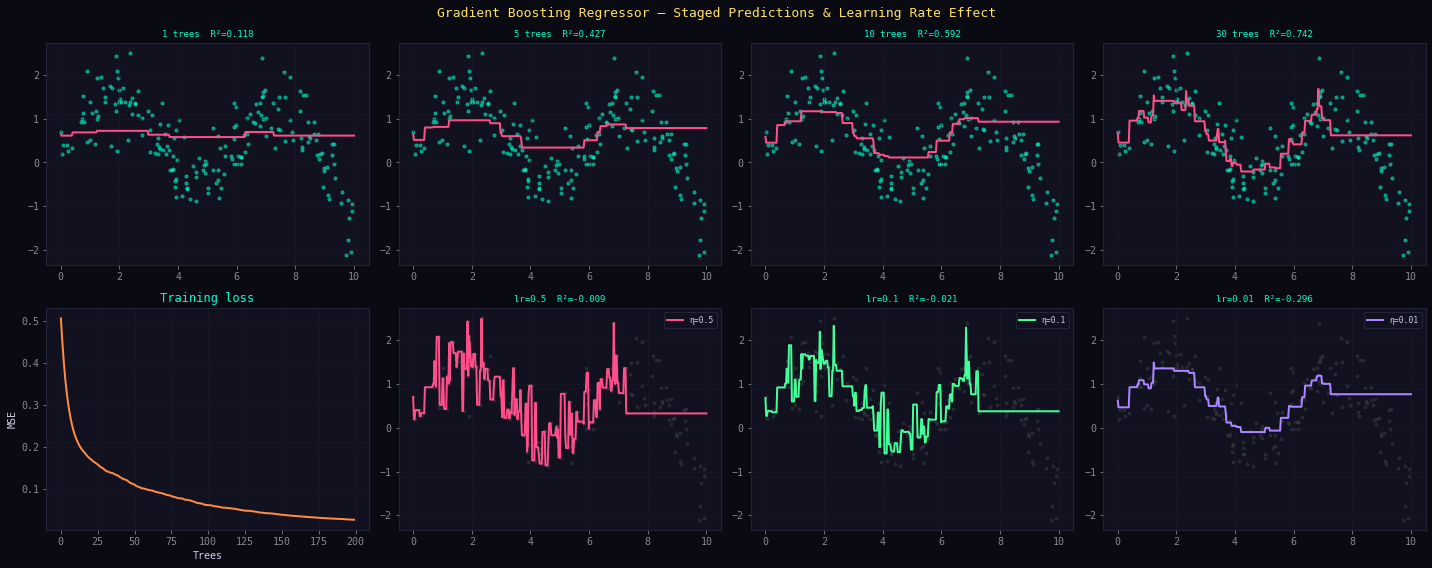

In [11]:
# ── Visualise staged predictions + loss curve ─────────────────────
x_plot = np.linspace(0, 10, 400).reshape(-1, 1)
stages = [1, 5, 10, 30, 80, 200]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Top row: staged predictions
for ax, s in zip(axes[0], stages):
    pred = gbr.predict(x_plot, n_trees=s)
    ax.scatter(x_r, y_r, color=CYAN, s=10, alpha=0.5)
    ax.plot(x_plot, pred, color=PINK, lw=2)
    ax.set_title(f'{s} trees  R²={r2(y_rtr, gbr.predict(X_rtr, n_trees=s)):.3f}', color=CYAN, fontsize=9)
    ax.grid(True)

# Bottom left: loss curve
axes[1][0].plot(gbr.train_losses, color=ORANGE, lw=2)
axes[1][0].set_xlabel('Trees'); axes[1][0].set_ylabel('MSE')
axes[1][0].set_title('Training loss', color=CYAN)
axes[1][0].grid(True)

# Bottom: effect of learning rate
for ax, lr, col in zip(axes[1][1:], [0.5, 0.1, 0.01], [PINK, GREEN, PURPLE]):
    g = GradientBoostingRegressor(n_estimators=200, learning_rate=lr, max_depth=3)
    g.fit(X_rtr, y_rtr)
    ax.plot(x_plot, g.predict(x_plot), color=col, lw=2, label=f'η={lr}')
    ax.scatter(x_r, y_r, color='#444', s=8, alpha=0.4)
    ax.set_title(f'lr={lr}  R²={r2(y_rte, g.predict(X_rte)):.3f}', color=CYAN, fontsize=9)
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle('Gradient Boosting Regressor — Staged Predictions & Learning Rate Effect',
             color=YELLOW, fontsize=13)
plt.tight_layout(); plt.show()

## 2.4 Gradient Boosting Classifier — From Scratch

For binary classification we use **log-loss** (binary cross-entropy):
$$L(y, F) = \log(1 + e^{-yF})$$

The pseudo-residual (negative gradient):
$$r_i = y_i - \sigma(F(x_i)) \quad \text{where } \sigma(z) = \frac{1}{1+e^{-z}}$$

This is just the **error between true label and predicted probability** — very intuitive.

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


class GradientBoostingClassifier:
    """
    Gradient Boosting for binary classification (log-loss).
    Labels: y ∈ {0, 1}
    Pseudo-residual: r_i = y_i − σ(F(x_i))
    """

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.lr           = learning_rate
        self.max_depth    = max_depth
        self.trees        = []
        self.F0           = None
        self.train_losses = []

    def _log_loss(self, y, F):
        p = sigmoid(F)
        p = np.clip(p, 1e-10, 1-1e-10)
        return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

    def fit(self, X, y):
        # Stage 0: log-odds of the mean
        p0 = np.clip(np.mean(y), 1e-7, 1 - 1e-7)
        self.F0 = np.log(p0 / (1 - p0))
        F = np.full(len(y), self.F0)

        for _ in range(self.n_estimators):
            # Pseudo-residuals = y - σ(F)
            residuals = y - sigmoid(F)

            tree = SimpleRegressionTree(max_depth=self.max_depth)
            tree.fit(X, residuals)

            F += self.lr * tree.predict(X)
            self.trees.append(tree)
            self.train_losses.append(self._log_loss(y, F))

        return self

    def predict_proba(self, X, n_trees=None):
        F = np.full(len(X), self.F0)
        for tree in (self.trees[:n_trees] if n_trees else self.trees):
            F += self.lr * tree.predict(X)
        return sigmoid(F)

    def predict(self, X, n_trees=None):
        return (self.predict_proba(X, n_trees) >= 0.5).astype(int)


# Convert y_moon from {-1,1} to {0,1} for classifier
y_tr01 = (y_tr == 1).astype(float)
y_te01 = (y_te == 1).astype(float)

gbc = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3)
gbc.fit(X_tr, y_tr01)

print(f'Train acc: {np.mean(gbc.predict(X_tr) == y_tr01):.4f}')
print(f'Test  acc: {np.mean(gbc.predict(X_te) == y_te01):.4f}')

Train acc: 0.9600
Test  acc: 0.3000


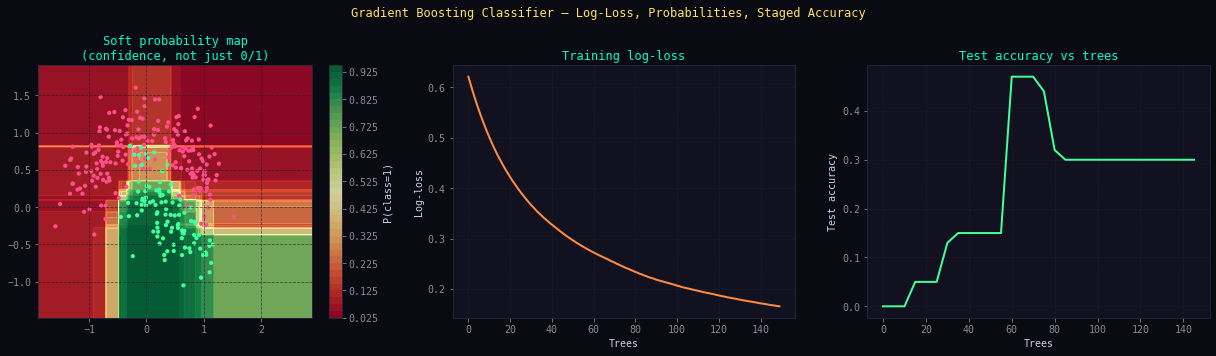

In [13]:
# ── Show probability map (soft boundary) ──────────────────────────
x0r = np.linspace(X_moon[:,0].min()-0.3, X_moon[:,0].max()+0.3, 250)
x1r = np.linspace(X_moon[:,1].min()-0.3, X_moon[:,1].max()+0.3, 250)
xx, yy = np.meshgrid(x0r, x1r)
Zgbc = gbc.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Probability heatmap
cm = axes[0].contourf(xx, yy, Zgbc, levels=40, cmap='RdYlGn', alpha=0.8)
plt.colorbar(cm, ax=axes[0], label='P(class=1)')
colors = [PINK if yi == 0 else GREEN for yi in y_tr01]
axes[0].scatter(X_tr[:,0], X_tr[:,1], c=colors, s=18, edgecolors='none')
axes[0].set_title('Soft probability map\n(confidence, not just 0/1)', color=CYAN)
axes[0].grid(True)

# Loss curve
axes[1].plot(gbc.train_losses, color=ORANGE, lw=2)
axes[1].set_xlabel('Trees'); axes[1].set_ylabel('Log-loss')
axes[1].set_title('Training log-loss', color=CYAN)
axes[1].grid(True)

# Staged accuracy
staged_acc = [np.mean(gbc.predict(X_te, n_trees=t+1) == y_te01)
              for t in range(0, 150, 5)]
axes[2].plot(range(0, 150, 5), staged_acc, color=GREEN, lw=2)
axes[2].set_xlabel('Trees'); axes[2].set_ylabel('Test accuracy')
axes[2].set_title('Test accuracy vs trees', color=CYAN)
axes[2].grid(True)

plt.suptitle('Gradient Boosting Classifier — Log-Loss, Probabilities, Staged Accuracy',
             color=YELLOW, fontsize=12)
plt.tight_layout(); plt.show()

## 2.5 Shrinkage: Learning Rate vs Number of Trees Trade-off

> **Lower learning rate + more trees = better generalisation** (but slower to train)
> 
> This is the fundamental regularisation strategy in Gradient Boosting.

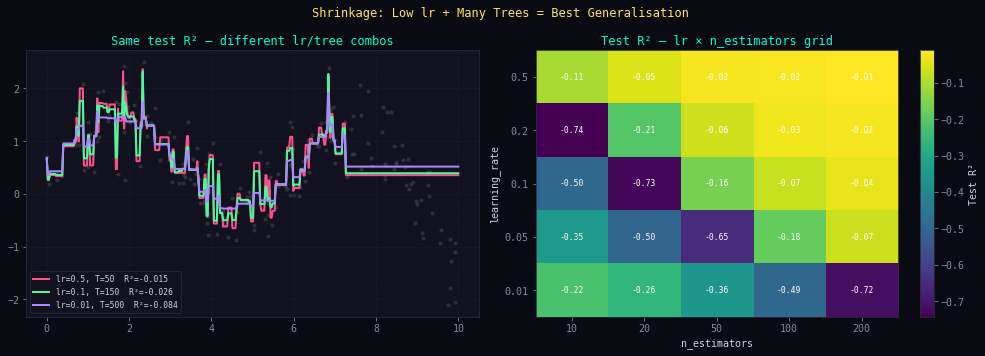

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = [(0.5, 50, PINK), (0.1, 150, GREEN), (0.01, 500, PURPLE)]
for lr, n_est, col in configs:
    g = GradientBoostingRegressor(n_estimators=n_est, learning_rate=lr, max_depth=3)
    g.fit(X_rtr, y_rtr)
    axes[0].plot(x_plot, g.predict(x_plot), color=col, lw=2,
                 label=f'lr={lr}, T={n_est}  R²={r2(y_rte, g.predict(X_rte)):.3f}')

axes[0].scatter(x_r, y_r, color='#444', s=10, alpha=0.5)
axes[0].set_title('Same test R² — different lr/tree combos', color=CYAN)
axes[0].legend(fontsize=8); axes[0].grid(True)

# Loss landscape: lr × n_estimators grid
lrs_grid = [0.5, 0.2, 0.1, 0.05, 0.01]
n_grid   = [10, 20, 50, 100, 200]
Z_grid   = np.zeros((len(lrs_grid), len(n_grid)))

for i, lr in enumerate(lrs_grid):
    for j, n_t in enumerate(n_grid):
        g = GradientBoostingRegressor(n_estimators=n_t, learning_rate=lr, max_depth=2)
        g.fit(X_rtr, y_rtr)
        Z_grid[i, j] = r2(y_rte, g.predict(X_rte))

im = axes[1].imshow(Z_grid, cmap='viridis', aspect='auto')
axes[1].set_xticks(range(len(n_grid)));   axes[1].set_xticklabels(n_grid)
axes[1].set_yticks(range(len(lrs_grid))); axes[1].set_yticklabels(lrs_grid)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('learning_rate')
axes[1].set_title('Test R² — lr × n_estimators grid', color=CYAN)
plt.colorbar(im, ax=axes[1], label='Test R²')
for i in range(len(lrs_grid)):
    for j in range(len(n_grid)):
        axes[1].text(j, i, f'{Z_grid[i,j]:.2f}', ha='center', va='center',
                     fontsize=8, color='white')

plt.suptitle('Shrinkage: Low lr + Many Trees = Best Generalisation', color=YELLOW, fontsize=12)
plt.tight_layout(); plt.show()

---
# PART III — XGBoost

## 3.1 What XGBoost Adds to Gradient Boosting

XGBoost (eXtreme Gradient Boosting, Chen & Guestrin 2016) is Gradient Boosting with several critical improvements:

| Feature | Standard GB | XGBoost |
|---------|-------------|----------|
| Gradient order | 1st (gradient) | **2nd (gradient + Hessian)** |
| Regularisation | None built-in | **L1 (α) + L2 (λ) on leaf weights** |
| Split finding | Brute force | **Approximate histogram-based** |
| Missing values | Manual | **Auto learns best direction** |
| Parallelism | Sequential | **Column-block parallelism** |
| Early stopping | Manual | **Built-in with eval set** |

## 3.2 The Second-Order Taylor Approximation

Instead of using only the gradient (first derivative), XGBoost approximates the loss using a **second-order Taylor expansion**:

$$L \approx \sum_i \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)$$

where:
- $g_i = \frac{\partial L}{\partial F_{t-1}(x_i)}$ — **gradient** (first derivative)
- $h_i = \frac{\partial^2 L}{\partial F_{t-1}(x_i)^2}$ — **Hessian** (second derivative, curvature)
- $\Omega(f_t) = \gamma T + \frac{1}{2}\lambda \sum_j w_j^2$ — **regularisation** (T = #leaves, $w_j$ = leaf weights)

This gives a **closed-form optimal leaf weight**:
$$w_j^* = -\frac{\sum_{i \in j} g_i}{\sum_{i \in j} h_i + \lambda}$$

And an **optimal split gain formula**:
$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

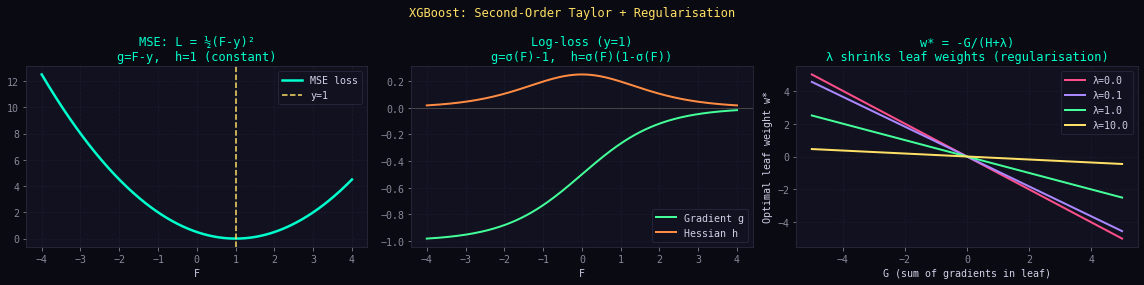

In [18]:
# ── Visualise Hessian for different losses ─────────────────────────
F_vals = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# MSE loss: g = F - y, h = 1 (constant Hessian)
y_true_ex = 1.0
g_mse = F_vals - y_true_ex
h_mse = np.ones_like(F_vals)

axes[0].plot(F_vals, 0.5*(F_vals - y_true_ex)**2, color=CYAN, lw=2.5, label='MSE loss')
axes[0].axvline(y_true_ex, color=YELLOW, lw=1.5, linestyle='--', label='y=1')
axes[0].set_title('MSE: L = ½(F-y)²\ng=F-y,  h=1 (constant)', color=CYAN)
axes[0].legend(); axes[0].grid(True); axes[0].set_xlabel('F')

# Log-loss: g = σ(F) - y,  h = σ(F)(1-σ(F))
p = sigmoid(F_vals)
g_ll = p - 1.0   # y=1
h_ll = p * (1 - p)
axes[1].plot(F_vals, g_ll, color=GREEN,  lw=2, label='Gradient g')
axes[1].plot(F_vals, h_ll, color=ORANGE, lw=2, label='Hessian h')
axes[1].axhline(0, color='#444', lw=1)
axes[1].set_title('Log-loss (y=1)\ng=σ(F)-1,  h=σ(F)(1-σ(F))', color=CYAN)
axes[1].legend(); axes[1].grid(True); axes[1].set_xlabel('F')

# Why Hessian matters: optimal leaf weight
lambdas = [0.0, 0.1, 1.0, 10.0]
G = np.linspace(-5, 5, 200)
H = 1.0  # constant for MSE
for lam, col in zip(lambdas, [PINK, PURPLE, GREEN, YELLOW]):
    w_opt = -G / (H + lam)
    axes[2].plot(G, w_opt, color=col, lw=2, label=f'λ={lam}')
axes[2].set_xlabel('G (sum of gradients in leaf)')
axes[2].set_ylabel('Optimal leaf weight w*')
axes[2].set_title('w* = -G/(H+λ)\nλ shrinks leaf weights (regularisation)', color=CYAN)
axes[2].legend(); axes[2].grid(True)

plt.suptitle('XGBoost: Second-Order Taylor + Regularisation', color=YELLOW, fontsize=12)
plt.tight_layout(); plt.show()

## 3.3 XGBoost Gain Formula — From Scratch Demonstration

In [19]:
def xgb_gain(G_L, H_L, G_R, H_R, lam=1.0, gamma=0.0):
    """
    XGBoost split gain formula.
    G_L, H_L = sum of gradients/hessians in left child
    G_R, H_R = sum of gradients/hessians in right child
    lam = L2 regularisation, gamma = min split gain threshold
    """
    return 0.5 * (G_L**2/(H_L+lam) + G_R**2/(H_R+lam)
                  - (G_L+G_R)**2/(H_L+H_R+lam)) - gamma

def xgb_leaf_weight(G, H, lam=1.0):
    """Optimal leaf weight: w* = -G/(H+λ)"""
    return -G / (H + lam)

# Walk through a concrete example
print('=== XGBoost Gain Formula — Worked Example ===')
print('Binary classification, y ∈ {0,1}, current F=0 for all samples')
print('Sample gradients g_i = σ(F_i) - y_i,  hessians h_i = σ(F_i)(1-σ(F_i))')
print()

y_ex = np.array([1, 1, 0, 0, 1, 0])
F_ex = np.zeros(6)
g_ex = sigmoid(F_ex) - y_ex
h_ex = sigmoid(F_ex) * (1 - sigmoid(F_ex))

print(f'y:          {y_ex}')
print(f'g = σ(F)-y: {np.round(g_ex, 3)}')
print(f'h = σ(F)(1-σ(F)): {np.round(h_ex, 3)}')

# Root gain vs two candidate splits
print()
for split_name, left_idx, right_idx in [
    ('Split A: [0,1,2] | [3,4,5]', [0,1,2], [3,4,5]),
    ('Split B: [0,1,4] | [2,3,5]', [0,1,4], [2,3,5]),
]:
    GL = g_ex[left_idx].sum();  HL = h_ex[left_idx].sum()
    GR = g_ex[right_idx].sum(); HR = h_ex[right_idx].sum()
    gain = xgb_gain(GL, HL, GR, HR, lam=1.0)
    wL = xgb_leaf_weight(GL, HL)
    wR = xgb_leaf_weight(GR, HR)
    print(f'{split_name}')
    print(f'  G_L={GL:.3f}  H_L={HL:.3f}  G_R={GR:.3f}  H_R={HR:.3f}')
    print(f'  Gain={gain:.4f}   w*_L={wL:.4f}   w*_R={wR:.4f}')
    print()

=== XGBoost Gain Formula — Worked Example ===
Binary classification, y ∈ {0,1}, current F=0 for all samples
Sample gradients g_i = σ(F_i) - y_i,  hessians h_i = σ(F_i)(1-σ(F_i))

y:          [1 1 0 0 1 0]
g = σ(F)-y: [-0.5 -0.5  0.5  0.5 -0.5  0.5]
h = σ(F)(1-σ(F)): [0.25 0.25 0.25 0.25 0.25 0.25]

Split A: [0,1,2] | [3,4,5]
  G_L=-0.500  H_L=0.750  G_R=0.500  H_R=0.750
  Gain=0.1429   w*_L=0.2857   w*_R=-0.2857

Split B: [0,1,4] | [2,3,5]
  G_L=-1.500  H_L=0.750  G_R=1.500  H_R=0.750
  Gain=1.2857   w*_L=0.8571   w*_R=-0.8571



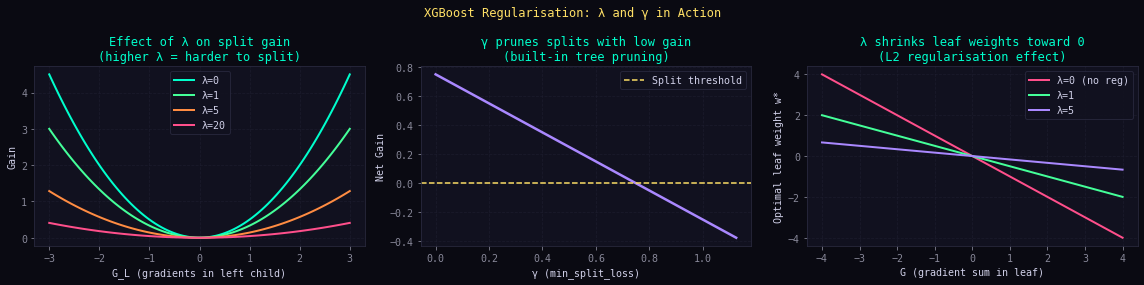

In [21]:
# ── Visualise how lambda (regularisation) affects gain surface ─────
G_vals = np.linspace(-3, 3, 100)
H_fixed = 2.0

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# for ax, H_L in [axes[0], axes[1], axes[2]]:
#     break  # just use axes directly below

# Gain vs G_L for different lambdas
for lam, col in [(0, CYAN), (1, GREEN), (5, ORANGE), (20, PINK)]:
    gains = [xgb_gain(g, H_fixed, -g, H_fixed, lam=lam) for g in G_vals]
    axes[0].plot(G_vals, gains, color=col, lw=2, label=f'λ={lam}')
axes[0].set_xlabel('G_L (gradients in left child)')
axes[0].set_ylabel('Gain')
axes[0].set_title('Effect of λ on split gain\n(higher λ = harder to split)', color=CYAN)
axes[0].legend(); axes[0].grid(True)

# Gain vs gamma (min_split_loss)
base_gain = xgb_gain(1.5, 2.0, -1.5, 2.0, lam=1.0, gamma=0)
gammas = np.linspace(0, base_gain * 1.5, 100)
net_gains = [xgb_gain(1.5, 2.0, -1.5, 2.0, lam=1.0, gamma=g) for g in gammas]
axes[1].plot(gammas, net_gains, color=PURPLE, lw=2.5)
axes[1].axhline(0, color=YELLOW, lw=1.5, linestyle='--', label='Split threshold')
axes[1].set_xlabel('γ (min_split_loss)'); axes[1].set_ylabel('Net Gain')
axes[1].set_title('γ prunes splits with low gain\n(built-in tree pruning)', color=CYAN)
axes[1].legend(); axes[1].grid(True)

# Regularisation: leaf weights with vs without lambda
G_range = np.linspace(-4, 4, 200)
for lam, col, lbl in [(0, PINK, 'λ=0 (no reg)'), (1, GREEN, 'λ=1'), (5, PURPLE, 'λ=5')]:
    axes[2].plot(G_range, xgb_leaf_weight(G_range, 1.0, lam), color=col, lw=2, label=lbl)
axes[2].set_xlabel('G (gradient sum in leaf)')
axes[2].set_ylabel('Optimal leaf weight w*')
axes[2].set_title('λ shrinks leaf weights toward 0\n(L2 regularisation effect)', color=CYAN)
axes[2].legend(); axes[2].grid(True)

plt.suptitle('XGBoost Regularisation: λ and γ in Action', color=YELLOW, fontsize=12)
plt.tight_layout(); plt.show()

## 3.4 XGBoost with the Library — Full Power

The internal split-finding (histogram approximation), parallel column blocks, GPU support, sparse-aware algorithm for missing values — these are engineering feats that can't be replicated simply. We use the `xgboost` library for full power.

In [22]:
try:
    import xgboost as xgb
    print(f'xgboost version: {xgb.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb
    print(f'xgboost installed: {xgb.__version__}')

xgboost installed: 2.1.4


In [ ]:
# ── Full benchmark: our scratch GBM vs xgboost ────────────────────
# Use a larger, harder dataset
n_bm = 600
X_bm = np.random.randn(n_bm, 8)
y_bm = (X_bm[:,0]**2 + np.sin(X_bm[:,1]) - X_bm[:,2]*X_bm[:,3]
        + 0.5*X_bm[:,4] + np.random.randn(n_bm)*0.5 > 0).astype(int)

tr_idx = np.random.choice(n_bm, 450, replace=False)
te_idx = np.setdiff1d(np.arange(n_bm), tr_idx)
X_btr, y_btr = X_bm[tr_idx], y_bm[tr_idx]
X_bte, y_bte = X_bm[te_idx], y_bm[te_idx]

# Our scratch GBM
gbc_bm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
gbc_bm.fit(X_btr, y_btr.astype(float))
scratch_acc = np.mean(gbc_bm.predict(X_bte) == y_bte)

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    reg_lambda=1.0, reg_alpha=0.0, gamma=0,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42,
    verbosity=0, use_label_encoder=False
)
xgb_model.fit(X_btr, y_btr,
              eval_set=[(X_bte, y_bte)],
              verbose=False)
xgb_acc = np.mean(xgb_model.predict(X_bte) == y_bte)

print(f'Scratch GBM  test accuracy: {scratch_acc:.4f}')
print(f'XGBoost      test accuracy: {xgb_acc:.4f}')
print(f'(XGBoost adds regularisation, 2nd-order, column sampling → generally better)')

## 3.5 XGBoost: Feature Importance & Early Stopping

In [ ]:
# ── Train with early stopping ─────────────────────────────────────
xgb_es = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    reg_lambda=2.0, gamma=0.1, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_es.fit(X_btr, y_btr,
           eval_set=[(X_btr, y_btr), (X_bte, y_bte)],
           early_stopping_rounds=20,
           verbose=False)

results = xgb_es.evals_result()
train_ll = results['validation_0']['logloss']
test_ll  = results['validation_1']['logloss']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Early stopping
axes[0].plot(train_ll, color=GREEN,  lw=2, label='Train log-loss')
axes[0].plot(test_ll,  color=ORANGE, lw=2, label='Test log-loss')
axes[0].axvline(xgb_es.best_iteration, color=YELLOW, lw=2, linestyle='--',
               label=f'Best iter={xgb_es.best_iteration}')
axes[0].set_xlabel('Trees'); axes[0].set_ylabel('Log-loss')
axes[0].set_title('Early Stopping: train/test curves\n(stops when test stops improving)', color=CYAN)
axes[0].legend(); axes[0].grid(True)

# Feature importance — 3 types
importance_types = ['weight', 'gain', 'cover']
for ax, imp_type, col in zip(axes[1:], importance_types[1:], [PURPLE, ORANGE]):
    scores = xgb_es.get_booster().get_score(importance_type=imp_type)
    feats  = [f'f{i}' for i in range(8)]
    vals   = [scores.get(f'f{i}', 0) for i in range(8)]
    sorted_idx = np.argsort(vals)[::-1]
    ax.barh(range(8), [vals[i] for i in sorted_idx], color=col, alpha=0.85)
    ax.set_yticks(range(8))
    ax.set_yticklabels([feats[i] for i in sorted_idx])
    ax.set_title(f'Feature importance: {imp_type}', color=CYAN)
    ax.grid(True, axis='x')

plt.suptitle('XGBoost: Early Stopping & Feature Importance Types', color=YELLOW, fontsize=12)
plt.tight_layout(); plt.show()
print(f'Best iteration: {xgb_es.best_iteration}  |  Best test score: {xgb_es.best_score:.4f}')

## 3.6 XGBoost Hyperparameter Deep-Dive

In [ ]:
# ── Subsample & colsample_bytree (stochastic GB) ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

params_grid = [
    ('subsample',         [0.3, 0.5, 0.7, 1.0]),
    ('colsample_bytree',  [0.3, 0.5, 0.8, 1.0]),
    ('max_depth',         [2, 3, 5, 8]),
    ('reg_lambda',        [0.01, 0.1, 1, 10]),
    ('reg_alpha',         [0, 0.1, 1, 5]),
    ('gamma',             [0, 0.1, 1, 5]),
]

base = dict(n_estimators=100, learning_rate=0.1, max_depth=3,
            reg_lambda=1.0, reg_alpha=0, gamma=0,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0, eval_metric='logloss')

for ax, (param, values) in zip(axes.ravel(), params_grid):
    tr_accs, te_accs = [], []
    for v in values:
        p = {**base, param: v}
        m = xgb.XGBClassifier(**p)
        m.fit(X_btr, y_btr, verbose=False)
        tr_accs.append(np.mean(m.predict(X_btr) == y_btr))
        te_accs.append(np.mean(m.predict(X_bte) == y_bte))

    ax.plot([str(v) for v in values], tr_accs, color=GREEN,  lw=2, marker='o', label='Train')
    ax.plot([str(v) for v in values], te_accs, color=ORANGE, lw=2, marker='s', label='Test')
    ax.set_title(f'{param}', color=CYAN)
    ax.set_ylabel('Accuracy'); ax.legend(fontsize=8); ax.grid(True)

plt.suptitle('XGBoost Hyperparameter Sensitivity Analysis', color=YELLOW, fontsize=13)
plt.tight_layout(); plt.show()

---
## Part 4 — Comparing All Three: AdaBoost vs GBM vs XGBoost

In [ ]:
# ── Side-by-side on the moons dataset ─────────────────────────────
y_tr_ada = np.where(y_tr01 == 1, 1, -1)   # adaboost needs {-1,+1}

models = [
    ('AdaBoost\n(100 stumps)',
     AdaBoostClassifier(n_estimators=100).fit(X_tr, y_tr_ada),
     lambda m, X: (m.predict(X) == 1).astype(int)),
    ('Gradient Boosting\n(150 trees)',
     GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3).fit(X_tr, y_tr01),
     lambda m, X: m.predict(X)),
    ('XGBoost\n(150 trees)',
     xgb.XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=3,
                        reg_lambda=1.0, random_state=42, verbosity=0, eval_metric='logloss').fit(X_tr, y_tr01),
     lambda m, X: m.predict(X)),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model, pred_fn) in zip(axes, models):
    x0r = np.linspace(X_moon[:,0].min()-0.3, X_moon[:,0].max()+0.3, 250)
    x1r = np.linspace(X_moon[:,1].min()-0.3, X_moon[:,1].max()+0.3, 250)
    xx, yy = np.meshgrid(x0r, x1r)
    Z = pred_fn(model, np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cmap_bg = ListedColormap(['#1a0d20', '#0d1a15'])
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors=[CYAN], linewidths=1.2, alpha=0.7)
    colors = [PINK if yi == 0 else GREEN for yi in y_te01]
    ax.scatter(X_te[:,0], X_te[:,1], c=colors, s=22, edgecolors='none', alpha=0.9)
    acc = np.mean(pred_fn(model, X_te) == y_te01)
    ax.set_title(f'{name}\nTest acc: {acc:.3f}', color=CYAN, fontsize=10)
    ax.grid(True)

plt.suptitle('AdaBoost vs Gradient Boosting vs XGBoost — Moons Dataset',
             color=YELLOW, fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ── Learning curve comparison ──────────────────────────────────────
ada_staged = ada.staged_score(X_te, y_te)
gbc_staged = [np.mean(gbc.predict(X_te, n_trees=t+1) == y_te01) for t in range(150)]

xgb_history = []
for n in range(1, 151):
    xgb_n = xgb.XGBClassifier(n_estimators=n, learning_rate=0.1, max_depth=3,
                                reg_lambda=1.0, random_state=42, verbosity=0, eval_metric='logloss')
    xgb_n.fit(X_tr, y_tr01, verbose=False)
    xgb_history.append(np.mean(xgb_n.predict(X_te) == y_te01))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(range(1, 101), ada_staged[:100], color=CYAN,   lw=2, label='AdaBoost')
ax.plot(range(1, 151), gbc_staged,       color=GREEN,  lw=2, label='Gradient Boosting (scratch)')
ax.plot(range(1, 151), xgb_history,      color=YELLOW, lw=2, label='XGBoost')
ax.set_xlabel('Number of trees / stumps')
ax.set_ylabel('Test accuracy')
ax.set_title('Staged Test Accuracy: All Three Algorithms', color=CYAN, fontsize=12)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Part 5 — Summary: The Boosting Family

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    BOOSTING CHEAT SHEET                                 │
├──────────────┬──────────────────┬───────────────────┬───────────────────┤
│              │  AdaBoost        │  Gradient Boost   │  XGBoost          │
├──────────────┼──────────────────┼───────────────────┼───────────────────┤
│ Weak learner │ Decision stump   │ Shallow tree      │ Shallow tree      │
│ Key idea     │ Re-weight data   │ Fit residuals     │ 2nd order + reg   │
│ Loss         │ Exponential      │ Any differentiable│ Any (Taylor exp.) │
│ Regularise   │ # stumps         │ lr, max_depth     │ λ, α, γ, subsamp  │
│ Sensitivity  │ Outliers (high)  │ Medium            │ Low (robust)      │
│ Speed        │ Fast             │ Moderate          │ Fast (parallel)   │
│ Missing data │ Manual impute    │ Manual impute     │ Auto handled      │
│ Early stop   │ Manual           │ Manual            │ Built-in          │
├──────────────┼──────────────────┼───────────────────┼───────────────────┤
│ Pseudo-resid │ y·exp(-α·h(x))   │ -∂L/∂F            │ -g_i / (h_i + λ)  │
│ Aggregation  │ Weighted sign    │ Sum of lr·trees   │ Sum of lr·trees   │
└──────────────┴──────────────────┴───────────────────┴───────────────────┘

Bias-Variance: All boosting methods reduce BIAS (not variance like RF).
Ensembles:     RF = parallel trees (variance↓). Boosting = sequential (bias↓).
In practice:   XGBoost / LightGBM win most structured-data competitions.
```

In [ ]:
print('''
╔═══════════════════════════════════════════════════════════════════════╗
║             Notebook complete! What you built & learned:              ║
╠═══════════════════════════════════════════════════════════════════════╣
║  ✅ ADABOOST (from scratch)                                           ║
║     • DecisionStump with weighted error minimisation                  ║
║     • α_t formula, weight update rule, weighted vote                  ║
║     • Staged decision boundary animation (8 panels)                   ║
║                                                                       ║
║  ✅ GRADIENT BOOSTING (from scratch)                                  ║
║     • Pseudo-residuals as negative gradient of loss                   ║
║     • GBM Regressor (MSE loss, gradient = residuals)                  ║
║     • GBM Classifier (log-loss, soft probability maps)                ║
║     • Shrinkage: lr × n_estimators trade-off grid                     ║
║                                                                       ║
║  ✅ XGBOOST (internals from scratch + library)                        ║
║     • 2nd-order Taylor expansion: gradients + Hessians                ║
║     • Optimal leaf weight: w* = -G/(H+λ)                              ║
║     • Split gain formula with λ and γ                                 ║
║     • Early stopping, feature importance types                        ║
║     • Full hyperparameter sensitivity analysis                        ║
║                                                                       ║
║  ✅ HEAD-TO-HEAD comparison: boundary + staged accuracy               ║
╚═══════════════════════════════════════════════════════════════════════╝
''')